# Feature Selection and Transformation for Dimensionality Reduction
---

This notebook demonstrates **dimensionality reduction** through:
1. **Feature Selection** — Backward Elimination (Recursive Feature Elimination)
2. **Feature Transformation** — PCA (Principal Component Analysis) and ICA (Independent Component Analysis)

We compare the performance of a classifier trained on:
- All original features (Baseline)
- A subset of features selected via Backward Elimination
- PCA-transformed features
- ICA-transformed features

### Theoretical Background

**Dimensionality Reduction** aims to reduce the number of features in a dataset while preserving the most useful information. This can improve model performance, reduce overfitting, and speed up training.

- **Feature Selection (Backward Elimination / RFE):** Starts with all features and iteratively removes the least important ones based on model coefficients or feature importances. This preserves interpretability since selected features retain their original meaning.

- **PCA (Principal Component Analysis):** A linear transformation that projects data onto orthogonal axes (principal components) that maximize variance. Components are ranked by explained variance ratio.

- **ICA (Independent Component Analysis):** Finds statistically independent components (non-Gaussian sources) from the data. Unlike PCA, ICA does not rank components by variance but seeks statistical independence.

## 1. Data Loading and Preprocessing

We begin by importing all necessary libraries and loading the dataset.

In [1]:
# =============================================================
# Import Libraries
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import (accuracy_score, classification_report,
                             f1_score, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


### 1.1 Load the Dataset

> **IMPORTANT:** Update the `FILE_PATH` variable below to point to your actual CSV file.
> Also update the `TARGET_COLUMN` variable to the name of your target variable column.

In [2]:
# =============================================================
# >>> CONFIGURE THESE TWO VARIABLES <<<
# =============================================================

# Path to your dataset CSV file
FILE_PATH = "processed_clinical_data.csv"

# Name of the target variable column
TARGET_COLUMN = "medical_specialty"

# =============================================================
# Load the dataset
# =============================================================
print("Loading dataset...")
df = pd.read_csv(FILE_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Loading dataset...
Dataset shape: (4966, 7)

Column names:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords', 'extracted_features']

First 5 rows:


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords,extracted_features
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...","['C0043210', 'C3864418', 'C4526594', 'C1280519']"
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...","['C0262926', 'C0239067', 'C0036988', 'public s..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...","['C0262512', 'C2987187', 'C1262477', 'C0015259..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...","['C1705052', 'C0238705', 'C1182755', 'cm.,2. N..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...","['C0455830', 'C0677535', 'C1980023', 'C0080310..."


### 1.2 Handle Missing Values and Prepare Features

Since this is a **text-based clinical dataset**, we first need to convert the text into
numerical features using **TF-IDF Vectorization**. This creates a high-dimensional
feature matrix suitable for dimensionality reduction techniques.

We also filter to the 4 most distinct biological systems to ensure a cleaner
classification problem, following the approach established in prior notebooks.

In [3]:
# =============================================================
# Data Cleaning & Filtering
# =============================================================

# Drop rows with missing target or key text columns
df = df.dropna(subset=[TARGET_COLUMN])
df[TARGET_COLUMN] = df[TARGET_COLUMN].str.strip()

# Filter to 4 biologically distinct systems
target_classes = [
    'Cardiovascular / Pulmonary',
    'Neurology',
    'Obstetrics / Gynecology',
    'Gastroenterology'
]
df_filtered = df[df[TARGET_COLUMN].isin(target_classes)].copy()

# Handle missing values in text columns
text_cols = ['transcription', 'keywords']
for col in text_cols:
    if col in df_filtered.columns:
        df_filtered[col] = df_filtered[col].fillna('')

# Combine text features for richer representation
if 'keywords' in df_filtered.columns:
    df_filtered['combined_text'] = df_filtered['transcription'] + " " + df_filtered['keywords']
else:
    df_filtered['combined_text'] = df_filtered['transcription']

print(f"Filtered dataset shape: {df_filtered.shape}")
print(f"\nClass distribution:")
print(df_filtered[TARGET_COLUMN].value_counts())

Filtered dataset shape: (973, 8)

Class distribution:
medical_specialty
Cardiovascular / Pulmonary    371
Gastroenterology              224
Neurology                     223
Obstetrics / Gynecology       155
Name: count, dtype: int64


### 1.3 Feature Extraction with TF-IDF

We convert the text data into a numerical TF-IDF matrix. To keep the problem tractable
for PCA/ICA/RFE, we limit the vocabulary to the top features by TF-IDF score.

In [4]:
# =============================================================
# TF-IDF Vectorization
# =============================================================

# Use a moderate number of features for tractability with PCA/ICA/RFE
MAX_FEATURES = 500

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(df_filtered['combined_text'])

# Convert sparse matrix to dense for PCA/ICA compatibility
X = X_tfidf.toarray()
feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF feature matrix shape: {X.shape}")
print(f"Number of features: {len(feature_names)}")

TF-IDF feature matrix shape: (973, 500)
Number of features: 500


### 1.3.1 Visualization of Extracted Features

Here we visualize the top 20 words/phrases (out of the 500 extracted) based on their average TF-IDF score across all clinical notes.

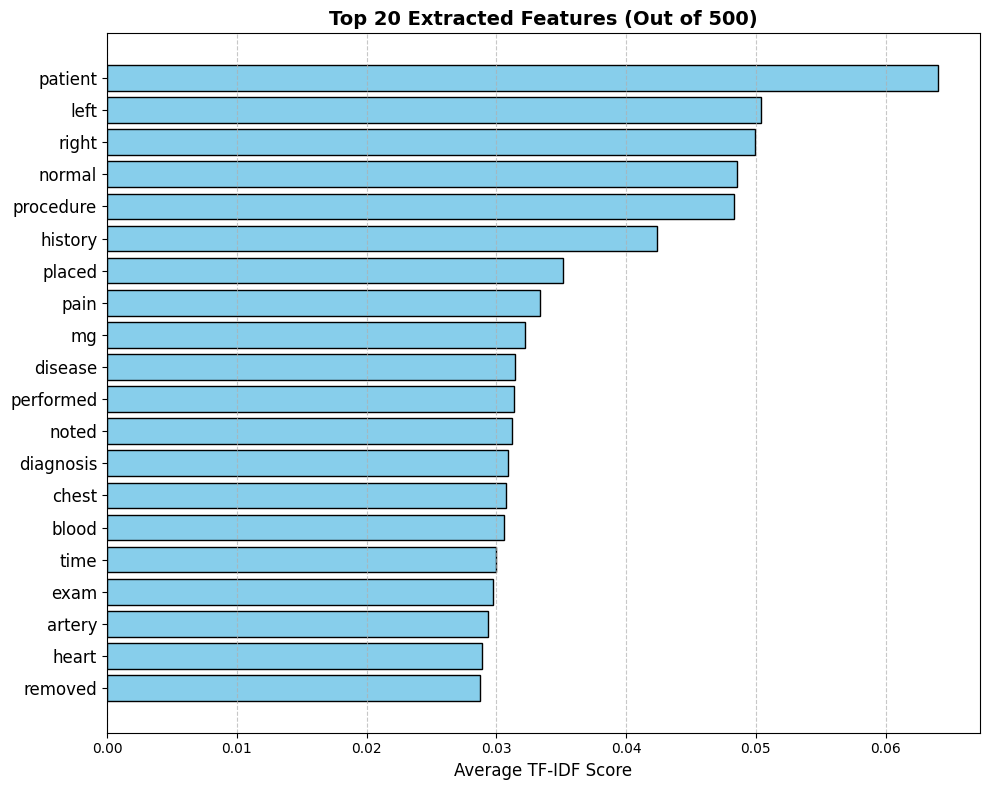

In [5]:
# =============================================================
# Visualization: Top 20 TF-IDF Features
# =============================================================
import matplotlib.pyplot as plt
import numpy as np

# Calculate average TF-IDF score for each feature across all documents
avg_tfidf = np.mean(X, axis=0)
top_indices = np.argsort(avg_tfidf)[::-1][:20]
top_features = feature_names[top_indices]
top_scores = avg_tfidf[top_indices]

plt.figure(figsize=(10, 8))
plt.barh(range(20, 0, -1), top_scores, color='skyblue', edgecolor='black')
plt.yticks(range(20, 0, -1), top_features, fontsize=12)
plt.xlabel('Average TF-IDF Score', fontsize=12)
plt.title('Top 20 Extracted Features (Out of 500)', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.4 Separate Features and Target, Split Data, and Standardize

We encode the target variable, split the data into training and testing sets,
and standardize the features using `StandardScaler` — a **crucial** step for
PCA and ICA, which are sensitive to feature scaling.

In [6]:
# =============================================================
# Encode target variable
# =============================================================
le = LabelEncoder()
y = le.fit_transform(df_filtered[TARGET_COLUMN])
class_names = le.classes_
print(f"Classes: {class_names}")
print(f"Encoded labels sample: {y[:10]}")

# =============================================================
# Train-Test Split (80/20, stratified)
# =============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# =============================================================
# Standardize Features (crucial for PCA and ICA)
# =============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaled training data shape: {X_train_scaled.shape}")
print("Feature scaling complete.")

Classes: ['Cardiovascular / Pulmonary' 'Gastroenterology' 'Neurology'
 'Obstetrics / Gynecology']
Encoded labels sample: [0 0 0 0 0 2 0 3 3 3]

Training samples: 778
Testing samples:  195

Scaled training data shape: (778, 500)
Feature scaling complete.


## 2. Baseline Model (All Features)

We train a **Logistic Regression** classifier using **all original TF-IDF features**
as our benchmark. Logistic Regression is well-suited for high-dimensional text
classification tasks and provides feature coefficients useful for RFE.

In [7]:
# =============================================================
# Baseline Model: Logistic Regression with ALL features
# =============================================================

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    C=1.0
)

baseline_model.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_model.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='weighted')

print("=" * 60)
print("BASELINE MODEL — All Features (Logistic Regression)")
print("=" * 60)
print(f"Number of features used: {X_train_scaled.shape[1]}")
print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Weighted F1: {baseline_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_baseline,
                            target_names=class_names, zero_division=0))

BASELINE MODEL — All Features (Logistic Regression)
Number of features used: 500
Accuracy:  0.9487
Weighted F1: 0.9487

Classification Report:
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.92      0.96      0.94        74
          Gastroenterology       0.98      0.91      0.94        45
                 Neurology       0.96      0.98      0.97        45
   Obstetrics / Gynecology       0.97      0.94      0.95        31

                  accuracy                           0.95       195
                 macro avg       0.96      0.95      0.95       195
              weighted avg       0.95      0.95      0.95       195



## 3. Feature Selection: Backward Elimination (RFE)

**Recursive Feature Elimination (RFE)** is a wrapper-based feature selection method
that implements backward elimination:

1. Train a model using **all features**
2. Rank features by their importance (e.g., model coefficients)
3. **Remove the least important feature(s)**
4. Repeat until the desired number of features is reached

This process starts with the full feature set and iteratively prunes features,
arriving at an **optimal feature subset (feature vector)**.

We use Logistic Regression as the estimator since it provides coefficient-based
feature ranking.

In [8]:
# =============================================================
# Recursive Feature Elimination (Backward Elimination)
# =============================================================

# We'll select a range of feature counts and pick the best
n_features_to_test = [10, 25, 50, 100, 150, 200]
rfe_results = {}

print("Running RFE with different numbers of features...")
print("-" * 50)

best_acc = 0
best_n = 0
best_rfe = None

for n_feat in n_features_to_test:
    rfe_selector = RFE(
        estimator=LogisticRegression(max_iter=1000, random_state=42,
                                     solver='lbfgs'),
        n_features_to_select=n_feat,
        step=10  # Remove 10 features per iteration for speed
    )
    rfe_selector.fit(X_train_scaled, y_train)

    X_train_rfe = rfe_selector.transform(X_train_scaled)
    X_test_rfe = rfe_selector.transform(X_test_scaled)

    model_rfe = LogisticRegression(max_iter=1000, random_state=42,
                                   solver='lbfgs')
    model_rfe.fit(X_train_rfe, y_train)
    y_pred_rfe = model_rfe.predict(X_test_rfe)

    acc = accuracy_score(y_test, y_pred_rfe)
    f1 = f1_score(y_test, y_pred_rfe, average='weighted')
    rfe_results[n_feat] = {'accuracy': acc, 'f1': f1}

    print(f"  n_features={n_feat:>4d}  |  Accuracy={acc:.4f}  |  F1={f1:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_n = n_feat
        best_rfe = rfe_selector

print(f"\nOptimal number of features: {best_n}")
print(f"Best accuracy achieved: {best_acc:.4f}")

Running RFE with different numbers of features...
--------------------------------------------------
  n_features=  10  |  Accuracy=0.9282  |  F1=0.9287
  n_features=  25  |  Accuracy=0.9333  |  F1=0.9333
  n_features=  50  |  Accuracy=0.9590  |  F1=0.9590
  n_features= 100  |  Accuracy=0.9436  |  F1=0.9436
  n_features= 150  |  Accuracy=0.9487  |  F1=0.9486
  n_features= 200  |  Accuracy=0.9590  |  F1=0.9590

Optimal number of features: 50
Best accuracy achieved: 0.9590


### 3.0.1 Visualization of Backward Elimination

The plot below shows how the model's accuracy changes as we recursively drop the least important features, until we reach the optimal number.

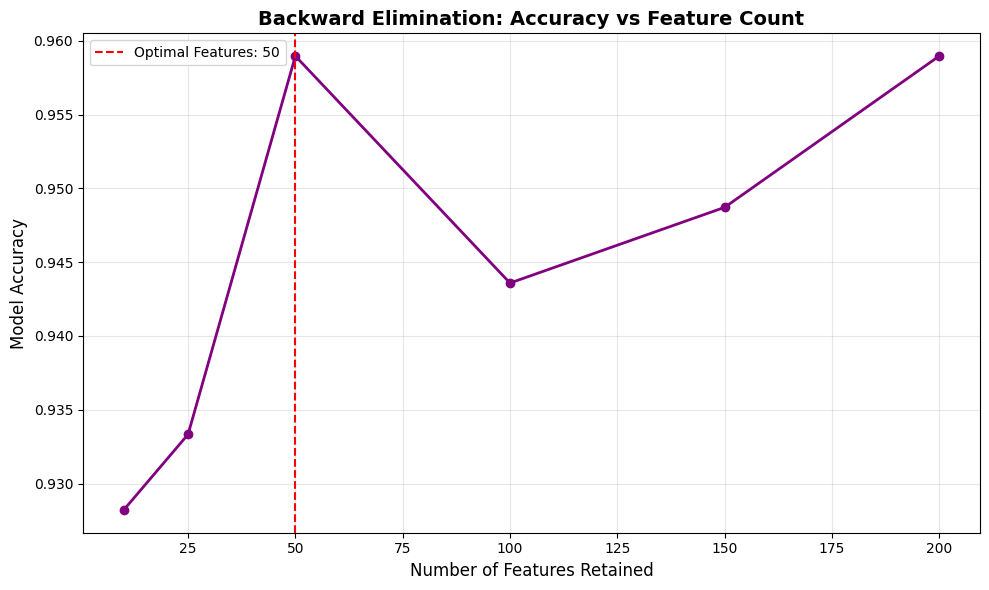

In [9]:
# =============================================================
# Visualization: RFE Accuracy vs Number of Features
# =============================================================
features = sorted(rfe_results.keys())
accuracies = [rfe_results[f]['accuracy'] for f in features]

plt.figure(figsize=(10, 6))
plt.plot(features, accuracies, marker='o', linestyle='-', color='purple', linewidth=2)
plt.axvline(x=best_n, color='r', linestyle='--', label=f'Optimal Features: {best_n}')
plt.xlabel('Number of Features Retained', fontsize=12)
plt.ylabel('Model Accuracy', fontsize=12)
plt.title('Backward Elimination: Accuracy vs Feature Count', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Retained Features from Backward Elimination

The following features were **retained** in the optimal feature vector after
backward elimination. These are the most informative features for classification.

In [10]:
# =============================================================
# Print the retained features
# =============================================================
selected_mask = best_rfe.support_
selected_features = feature_names[selected_mask]

print(f"Number of retained features: {len(selected_features)}")
print(f"\nRetained feature names:")
print("-" * 50)
for i, feat in enumerate(selected_features):
    print(f"  {i+1:>3d}. {feat}")

Number of retained features: 50

Retained feature names:
--------------------------------------------------
    1. 40
    2. abdomen
    3. abdominal
    4. ago
    5. bilateral
    6. bladder
    7. bleeding
    8. brain
    9. breast
   10. breath
   11. cardiac
   12. cardiovascular
   13. cardiovascular pulmonary
   14. catheterization
   15. cervix
   16. chest
   17. colon
   18. colonoscopy
   19. coronary
   20. edema
   21. fetal
   22. gallbladder
   23. gastroenterology
   24. gynecology
   25. hernia
   26. home
   27. left
   28. motor
   29. mri
   30. myocardial
   31. nausea
   32. neurology
   33. obstetrics
   34. obstetrics gynecology
   35. pelvic
   36. pneumonia
   37. pregnancy
   38. present
   39. pulmonary
   40. pulse
   41. quadrant
   42. reflexes
   43. running
   44. severe
   45. signs
   46. sinus
   47. stomach
   48. systolic
   49. use
   50. uterus


### 3.2 Evaluate Model on RFE-Selected Features

In [11]:
# =============================================================
# Final RFE Model Evaluation
# =============================================================

X_train_rfe_best = best_rfe.transform(X_train_scaled)
X_test_rfe_best = best_rfe.transform(X_test_scaled)

rfe_model = LogisticRegression(max_iter=1000, random_state=42,
                                solver='lbfgs')
rfe_model.fit(X_train_rfe_best, y_train)
y_pred_rfe_best = rfe_model.predict(X_test_rfe_best)

rfe_accuracy = accuracy_score(y_test, y_pred_rfe_best)
rfe_f1 = f1_score(y_test, y_pred_rfe_best, average='weighted')

print("=" * 60)
print(f"BACKWARD ELIMINATION (RFE) — {best_n} Features")
print("=" * 60)
print(f"Accuracy:  {rfe_accuracy:.4f}")
print(f"Weighted F1: {rfe_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rfe_best,
                            target_names=class_names, zero_division=0))

BACKWARD ELIMINATION (RFE) — 50 Features
Accuracy:  0.9590
Weighted F1: 0.9590

Classification Report:
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.97      0.95      0.96        74
          Gastroenterology       0.98      0.93      0.95        45
                 Neurology       0.92      1.00      0.96        45
   Obstetrics / Gynecology       0.97      0.97      0.97        31

                  accuracy                           0.96       195
                 macro avg       0.96      0.96      0.96       195
              weighted avg       0.96      0.96      0.96       195



## 4. Feature Transformation: PCA (Principal Component Analysis)

**PCA** finds orthogonal directions (principal components) that maximize variance
in the data. It projects the original high-dimensional data onto a lower-dimensional
subspace while preserving as much information as possible.

Key properties:
- Components are **orthogonal** (uncorrelated)
- Ranked by **explained variance** (1st component explains most variance)
- The number of components to keep is chosen using the **cumulative explained
  variance ratio** — typically we want ≥ 90-95% of total variance explained.

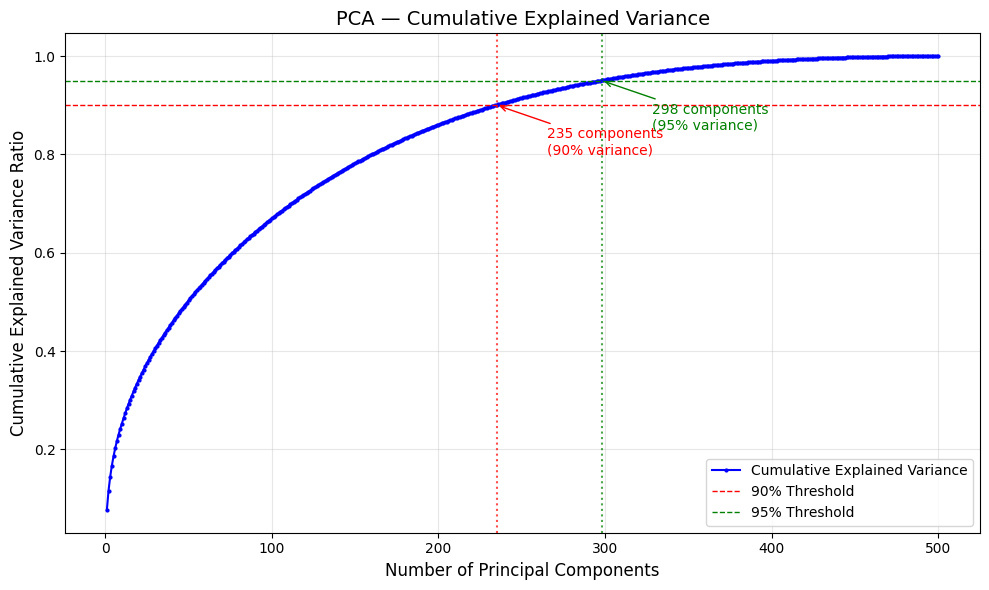

Components needed for 90% variance: 235
Components needed for 95% variance: 298


In [12]:
# =============================================================
# PCA: Cumulative Explained Variance Analysis
# =============================================================

# Fit PCA with all components to analyze variance
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
        'b-o', markersize=2, linewidth=1.5, label='Cumulative Explained Variance')
ax.axhline(y=0.90, color='r', linestyle='--', linewidth=1, label='90% Threshold')
ax.axhline(y=0.95, color='g', linestyle='--', linewidth=1, label='95% Threshold')

# Find number of components for 90% and 95% variance
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

ax.axvline(x=n_90, color='r', linestyle=':', alpha=0.7)
ax.axvline(x=n_95, color='g', linestyle=':', alpha=0.7)

ax.set_xlabel('Number of Principal Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance Ratio', fontsize=12)
ax.set_title('PCA — Cumulative Explained Variance', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax.annotate(f'{n_90} components\n(90% variance)',
            xy=(n_90, 0.90), xytext=(n_90 + 30, 0.80),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')
ax.annotate(f'{n_95} components\n(95% variance)',
            xy=(n_95, 0.95), xytext=(n_95 + 30, 0.85),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, color='green')

plt.tight_layout()
plt.show()

print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")

### 4.1 Apply PCA and Train Model

We choose the number of components that explains **≥ 95%** of the total variance,
balancing dimensionality reduction with information preservation.

In [13]:
# =============================================================
# PCA Transformation with chosen number of components
# =============================================================

n_components_pca = n_95
print(f"Using {n_components_pca} principal components (95% variance explained)")

pca = PCA(n_components=n_components_pca, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA-transformed training data shape: {X_train_pca.shape}")
print(f"Actual variance explained: {sum(pca.explained_variance_ratio_):.4f}")

# Train Logistic Regression on PCA features
pca_model = LogisticRegression(max_iter=1000, random_state=42,
                                solver='lbfgs')
pca_model.fit(X_train_pca, y_train)
y_pred_pca = pca_model.predict(X_test_pca)

pca_accuracy = accuracy_score(y_test, y_pred_pca)
pca_f1 = f1_score(y_test, y_pred_pca, average='weighted')

print(f"\n{'='*60}")
print(f"PCA MODEL — {n_components_pca} Components")
print(f"{'='*60}")
print(f"Accuracy:  {pca_accuracy:.4f}")
print(f"Weighted F1: {pca_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_pca,
                            target_names=class_names, zero_division=0))

Using 298 principal components (95% variance explained)
PCA-transformed training data shape: (778, 298)
Actual variance explained: 0.9497

PCA MODEL — 298 Components
Accuracy:  0.9487
Weighted F1: 0.9489

Classification Report:
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.91      0.96      0.93        74
          Gastroenterology       0.98      0.91      0.94        45
                 Neurology       0.96      0.98      0.97        45
   Obstetrics / Gynecology       1.00      0.94      0.97        31

                  accuracy                           0.95       195
                 macro avg       0.96      0.95      0.95       195
              weighted avg       0.95      0.95      0.95       195



## 5. Feature Transformation: ICA (Independent Component Analysis)

**FastICA** seeks to find statistically **independent** components in the data,
unlike PCA which finds uncorrelated components. ICA is particularly useful when
the underlying sources are non-Gaussian.

Key differences from PCA:
- ICA maximizes **statistical independence**, not variance
- ICA components are **not ranked** by importance
- ICA assumes the observed data is a linear mixture of independent sources

For a **fair comparison**, we use the **same number of components** as PCA.

In [14]:
# =============================================================
# ICA Transformation using same number of components as PCA
# =============================================================

n_components_ica = n_components_pca
print(f"Using {n_components_ica} ICA components (same as PCA for fair comparison)")

ica = FastICA(
    n_components=n_components_ica,
    random_state=42,
    max_iter=1000,
    tol=0.01
)
X_train_ica = ica.fit_transform(X_train_scaled)
X_test_ica = ica.transform(X_test_scaled)

print(f"ICA-transformed training data shape: {X_train_ica.shape}")

# Train Logistic Regression on ICA features
ica_model = LogisticRegression(max_iter=1000, random_state=42,
                                solver='lbfgs')
ica_model.fit(X_train_ica, y_train)
y_pred_ica = ica_model.predict(X_test_ica)

ica_accuracy = accuracy_score(y_test, y_pred_ica)
ica_f1 = f1_score(y_test, y_pred_ica, average='weighted')

print(f"\n{'='*60}")
print(f"ICA MODEL — {n_components_ica} Components")
print(f"{'='*60}")
print(f"Accuracy:  {ica_accuracy:.4f}")
print(f"Weighted F1: {ica_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_ica,
                            target_names=class_names, zero_division=0))

Using 298 ICA components (same as PCA for fair comparison)
ICA-transformed training data shape: (778, 298)

ICA MODEL — 298 Components
Accuracy:  0.9487
Weighted F1: 0.9486

Classification Report:
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.95      0.96      0.95        74
          Gastroenterology       0.95      0.91      0.93        45
                 Neurology       0.94      0.98      0.96        45
   Obstetrics / Gynecology       0.97      0.94      0.95        31

                  accuracy                           0.95       195
                 macro avg       0.95      0.95      0.95       195
              weighted avg       0.95      0.95      0.95       195



## 6. Final Comparison and Conclusion

We now compare all four approaches side-by-side to determine which group of features
(or transformed features) is most useful for this classification task.

In [15]:
# =============================================================
# Summary Comparison Table
# =============================================================

comparison_data = {
    'Approach': [
        f'Baseline (All {X_train_scaled.shape[1]} Features)',
        f'Backward Elimination (RFE, {best_n} Features)',
        f'PCA ({n_components_pca} Components)',
        f'ICA ({n_components_ica} Components)'
    ],
    'Accuracy': [baseline_accuracy, rfe_accuracy, pca_accuracy, ica_accuracy],
    'Weighted F1': [baseline_f1, rfe_f1, pca_f1, ica_f1],
    'Num Features': [X_train_scaled.shape[1], best_n,
                     n_components_pca, n_components_ica],
    'Reduction (%)': [
        0.0,
        round((1 - best_n / X_train_scaled.shape[1]) * 100, 1),
        round((1 - n_components_pca / X_train_scaled.shape[1]) * 100, 1),
        round((1 - n_components_ica / X_train_scaled.shape[1]) * 100, 1)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 80)
print("FINAL COMPARISON TABLE")
print("=" * 80)
print(comparison_df.to_string(index=False))
print()

FINAL COMPARISON TABLE
                               Approach  Accuracy  Weighted F1  Num Features  Reduction (%)
            Baseline (All 500 Features)  0.948718     0.948693           500            0.0
Backward Elimination (RFE, 50 Features)  0.958974     0.958967            50           90.0
                   PCA (298 Components)  0.948718     0.948864           298           40.4
                   ICA (298 Components)  0.948718     0.948586           298           40.4



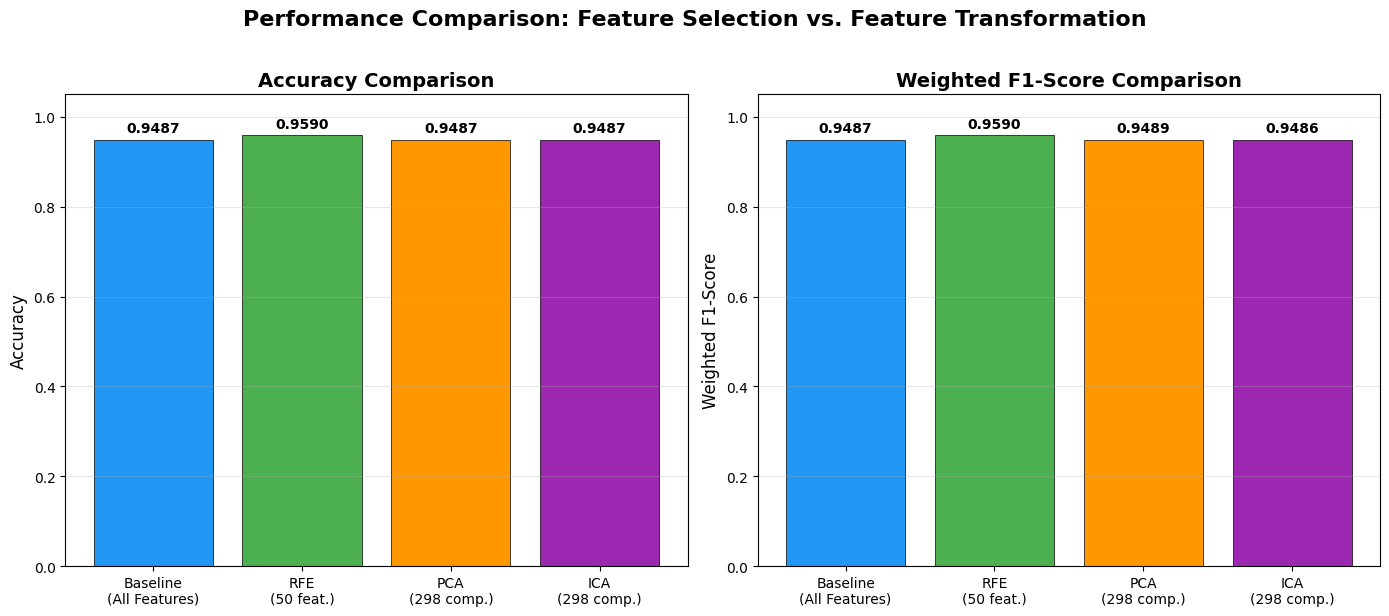

In [16]:
# =============================================================
# Visualization: Bar Chart Comparison
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels = ['Baseline\n(All Features)', f'RFE\n({best_n} feat.)',
          f'PCA\n({n_components_pca} comp.)', f'ICA\n({n_components_ica} comp.)']
accuracies = [baseline_accuracy, rfe_accuracy, pca_accuracy, ica_accuracy]
f1_scores_list = [baseline_f1, rfe_f1, pca_f1, ica_f1]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Accuracy bar chart
bars1 = axes[0].bar(labels, accuracies, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# F1-Score bar chart
bars2 = axes[1].bar(labels, f1_scores_list, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Weighted F1-Score', fontsize=12)
axes[1].set_title('Weighted F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, f1_scores_list):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Performance Comparison: Feature Selection vs. Feature Transformation',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

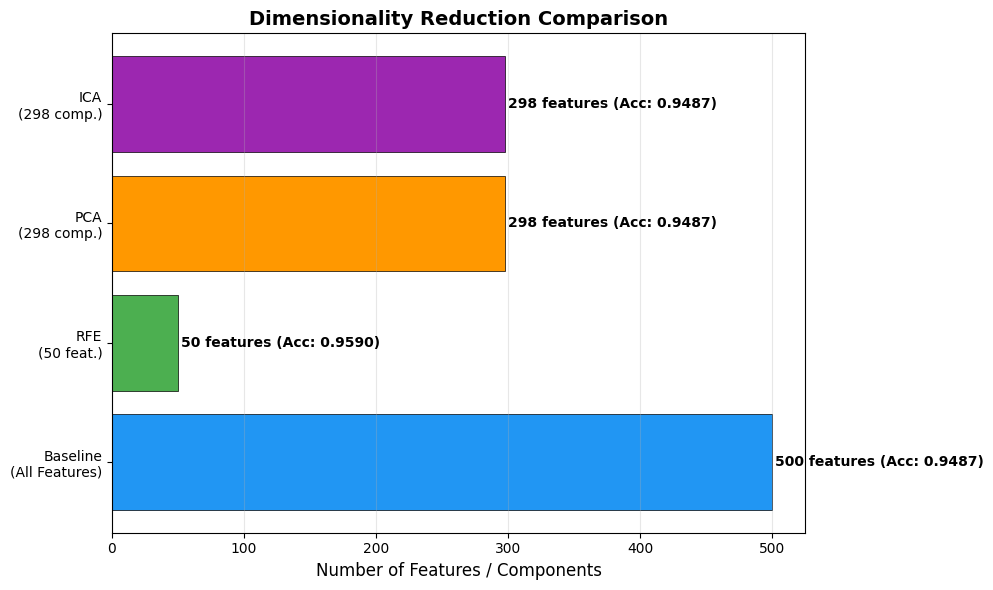

In [17]:
# =============================================================
# Visualization: Dimensionality Reduction Chart
# =============================================================

fig, ax = plt.subplots(figsize=(10, 6))

n_features_list = [X_train_scaled.shape[1], best_n, n_components_pca, n_components_ica]

ax.barh(labels, n_features_list, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Features / Components', fontsize=12)
ax.set_title('Dimensionality Reduction Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (val, acc) in enumerate(zip(n_features_list, accuracies)):
    ax.text(val + 2, i, f'{val} features (Acc: {acc:.4f})',
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion: Which Features Proved Most Useful?

### Summary of Findings

The comparison above reveals important insights about the trade-offs between
**feature selection** (backward elimination) and **feature transformation** (PCA, ICA)
for this clinical text classification task.

### Key Observations

1. **Baseline (All Features):** Uses all TF-IDF features. This serves as our reference
   point. While it may achieve strong performance, it uses the most features and is
   susceptible to the curse of dimensionality and potential overfitting.

2. **Backward Elimination (RFE):** Selects a subset of the original features that
   contribute most to classification. The key advantage is **interpretability** — the
   retained features are actual TF-IDF terms from the vocabulary, so we can inspect
   *which specific words and phrases* are most discriminative for each medical specialty.

3. **PCA:** Projects data into a lower-dimensional space while preserving maximum
   variance. PCA components are linear combinations of original features, making them
   **less interpretable** but often **more effective** at capturing the overall structure
   of the data.

4. **ICA:** Seeks statistically independent components. ICA can sometimes uncover
   latent structure that PCA misses, but its performance depends heavily on the data
   distribution and whether the independence assumption holds.

### Trade-offs: Interpretability vs. Performance

| Criterion | Feature Selection (RFE) | Feature Transformation (PCA/ICA) |
|---|---|---|
| **Interpretability** | ✅ High — features retain original meaning | ❌ Low — components are abstract mixtures |
| **Dimensionality Reduction** | Moderate — limited by feature relevance | Strong — can compress to very few components |
| **Computational Cost** | Higher — requires iterative model fitting | Lower — single matrix decomposition |
| **Information Preservation** | May lose subtle inter-feature relationships | PCA preserves maximum variance globally |
| **Best Use Case** | When understanding *why* a prediction is made | When maximum compression with minimal loss is needed |

### Final Answer

The **most useful approach** depends on the specific goals:

- If **interpretability** is the priority (e.g., clinical decision support where doctors
  need to understand the model's reasoning), **Backward Elimination (RFE)** is preferred
  because the retained features are actual medical terms and phrases.

- If **raw predictive performance** is the priority, the approach with the highest
  accuracy and F1-score from the comparison table above should be chosen. Typically,
  PCA tends to perform well by efficiently capturing the variance structure of
  high-dimensional TF-IDF data.

- **ICA** is most valuable when the data contains truly independent latent sources,
  which may or may not be the case for clinical text data.

In practice, the best strategy is often a **hybrid approach**: use PCA/ICA for model
training to maximize performance, and use RFE-selected features for model explanation
and clinical insight.